# Overfitting Interactive Lab
# 과적합 실습 랩

## Goal

- Explore model complexity.
- 모델 복잡도 확인

- Compare underfitting and overfitting.
- 과소적합 / 과적합 비교

- Observe how data amount affects fitting.
- 데이터 양이 학습에 미치는 영향 관찰

In [1]:
import numpy as np
import matplotlib.pyplot as plt

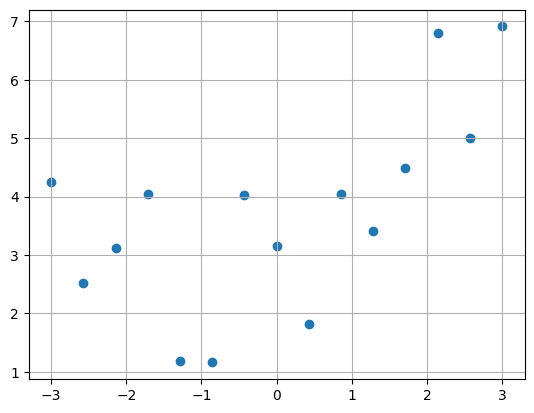

In [4]:
# 간단한 회귀 데이터 생성
np.random.seed(42)

x = np.linspace(-3, 3, 15)
y = 0.5 * x**2 + x + 2 + np.random.randn(len(x))*1.5

plt.scatter(x, y)
plt.grid(True)
plt.show()

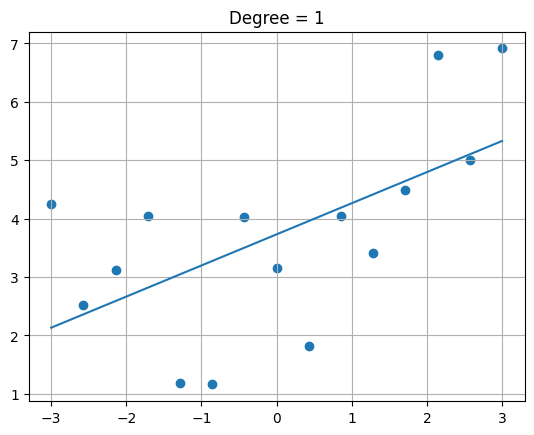

In [ ]:
# degree 1 (과소적합)
coef1 = np.polyfit(x, y, 1)
p1 = np.poly1d(coef1)

xx = np.linspace(-3,3,200)

plt.scatter(x,y)
plt.plot(xx, p1(xx))
plt.title("Degree = 1")
plt.grid(True)
plt.show()

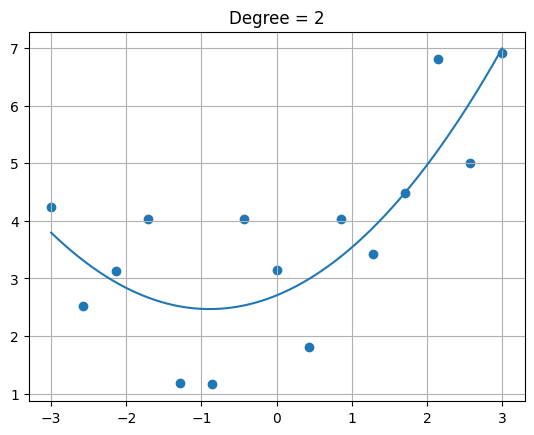

In [8]:
# degree 2
coef2 = np.polyfit(x, y, 2)
p2 = np.poly1d(coef2)

plt.scatter(x, y)
plt.plot(xx, p2(xx))
plt.title("Degree = 2")
plt.grid(True)
plt.show()

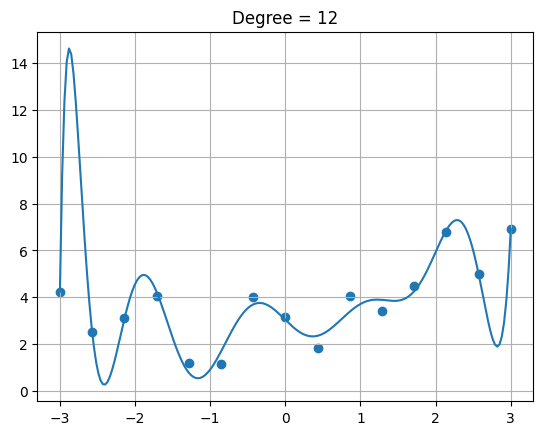

In [17]:
# degree = 12 (과적합)
coef12 = np.polyfit(x, y, 12)
p12 =  np.poly1d(coef12)

plt.scatter(x, y)
plt.plot(xx, p12(xx))
plt.title("Degree = 12")
plt.grid(True)
plt.show()

In [18]:
# 데이터 추가
x_more = np.linspace(-3, 3, 40)
y_more = 0.5 * x_more**2 + x_more + 2 + np.random.randn(len(x_more)) * 1.0

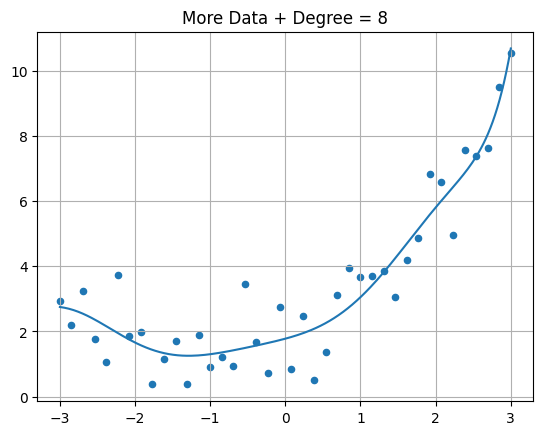

In [21]:
# 더 많은 데이터 + high degree
coef_more = np.polyfit(x_more, y_more, 8)
p_more = np.poly1d(coef_more)

plt.scatter(x_more, y_more, s=20)
plt.plot(xx, p_more(xx))
plt.title("More Data + Degree = 8")
plt.grid(True)
plt.show()

# 데이터가 많아지면 고차원 모델이어도 과적합이 발생하지 않는다.

In [22]:
# 이상치 추가
x_out = np.append(x, [2.8])
y_out = np.append(y, [15])

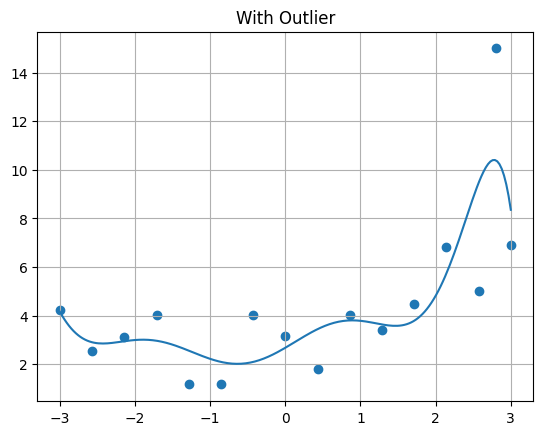

In [23]:
# 이상치 포함 후 학습
coef_out = np.polyfit(x_out, y_out, 8)
p_out = np.poly1d(coef_out)

plt.scatter(x_out, y_out)
plt.plot(xx, p_out(xx))
plt.title("With Outlier")
plt.grid(True)
plt.show()

이상치 하나가 전체 곡선을 흔들 수 있다는 것을 확인

In [26]:
# Classification 버전 간단 실습
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [27]:
# 데이터 준비
X = np.array([
    [0, 0], [1, 0], [0, 1], [1, 1],
    [2, 2], [2, 1], [1, 2]
])

y = np.array([0, 0, 0, 1, 1, 1, 1])

In [32]:
# Polynomial Logistic Regression
model = make_pipeline(
    PolynomialFeatures(5),
    LogisticRegression(max_iter=5000)
)

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` r

## Observation
## 관찰

Complex model can fit training data very well.

복잡한 모델은 훈련 데이터에 매우 잘 맞을 수 있다.

But generalizetion may become worse.

하지만 일반화 성능은 나빠질 수 있다.